<a href="https://colab.research.google.com/github/4541kiet-divakar/Divakar4541/blob/main/STUDENT_GRADE_CURVING_SYSTEMSY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Target mean M = 64.008, target std S = 15.280, cap = 100
S requested = 15.280, S allowed by cap = 14.109, S used = 14.109

--- Gauss elimination for Prof. A (easy) ---
Augmented [A|b]:
[[78.3     1.      0.     64.0083]
 [ 6.5468  0.      0.     14.1095]
 [95.      1.     -1.      0.    ]]
Swap R1 <-> R3
R2 <- R2 - (0.0689)*R1
R3 <- R3 - (0.8242)*R1
[[95.      1.     -1.      0.    ]
 [ 0.     -0.0689  0.0689 14.1095]
 [ 0.      0.1758  0.8242 64.0083]]
Swap R2 <-> R3
R3 <- R3 - (-0.3920)*R2
[[95.      1.     -1.      0.    ]
 [ 0.      0.1758  0.8242 64.0083]
 [ 0.      0.      0.392  39.2021]]
[[95.      1.     -1.      0.    ]
 [ 0.      0.1758  0.8242 64.0083]
 [ 0.      0.      0.392  39.2021]]

--- Gauss elimination for Prof. B (medium) ---
Augmented [A|b]:
[[65.225   1.      0.     64.0083]
 [ 8.6617  0.      0.     14.1095]
 [83.      1.     -1.      0.    ]]
Swap R1 <-> R3
R2 <- R2 - (0.1044)*R1
R3 <- R3 - (0.7858)*R1
[[83.      1.     -1.      0.    ]
 [ 0.     -0.1044  0.104

,Raw mean,Raw std,Scale a,Shift b,Curved top score c
Prof. A (easy),78.300,6.547,2.155,-104.743,100.000
Prof. B (medium),65.225,8.662,1.629,-42.241,92.963
Prof. C (hard),48.500,11.677,1.208,5.405,97.237



BEFORE vs AFTER CURVING


,Mean (raw),Std (raw),Max (raw),Mean (curved),Std (curved),Max (curved),Min (curved)
Professor,,,,,,,
Prof. A (easy),78.300,6.547,95.000,64.008,14.109,100.000,28.879
Prof. B (medium),65.225,8.662,83.000,64.008,14.109,92.963,31.063
Prof. C (hard),48.500,11.677,76.000,64.008,14.109,97.237,36.821


Means match target : True
Stds match target  : True
Within cap 100   : True

Symbolic solution:
  a = S/sigma
  b = M - S*mu/sigma
  c = (M*sigma - S*mu + S*x_max)/sigma

Numeric check for Prof. A (easy):
  SymPy : [2.1551896207584824, -104.74301397205582, 100.0]
  Gauss : [np.float64(2.155189620758482), np.float64(-104.74301397205579), np.float64(100.00000000000001)]


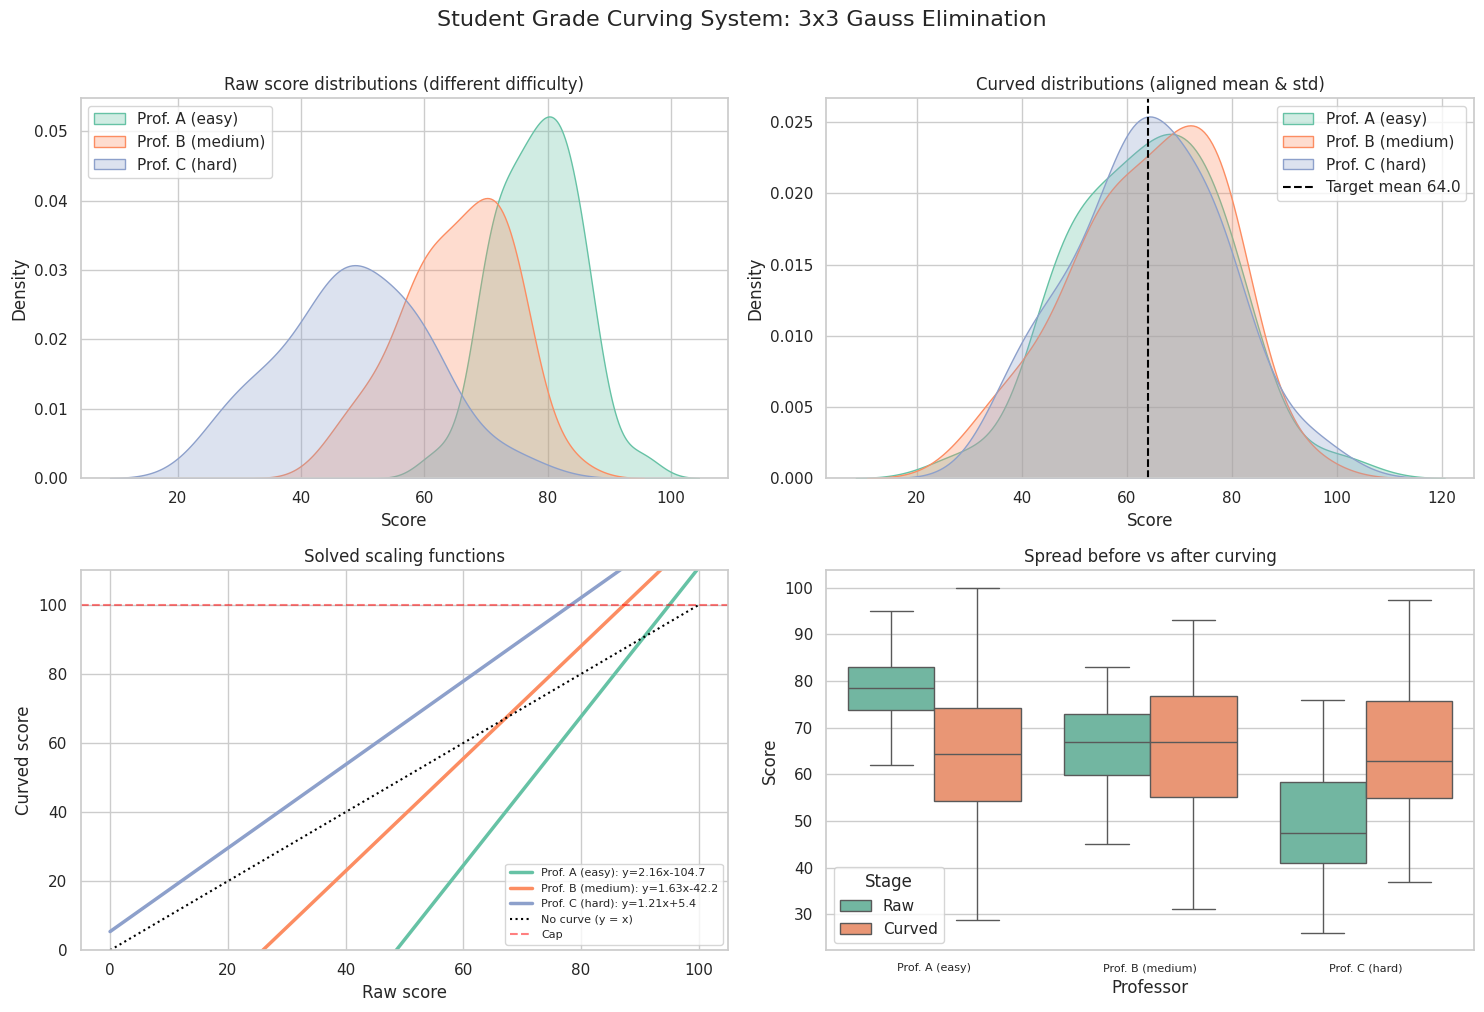

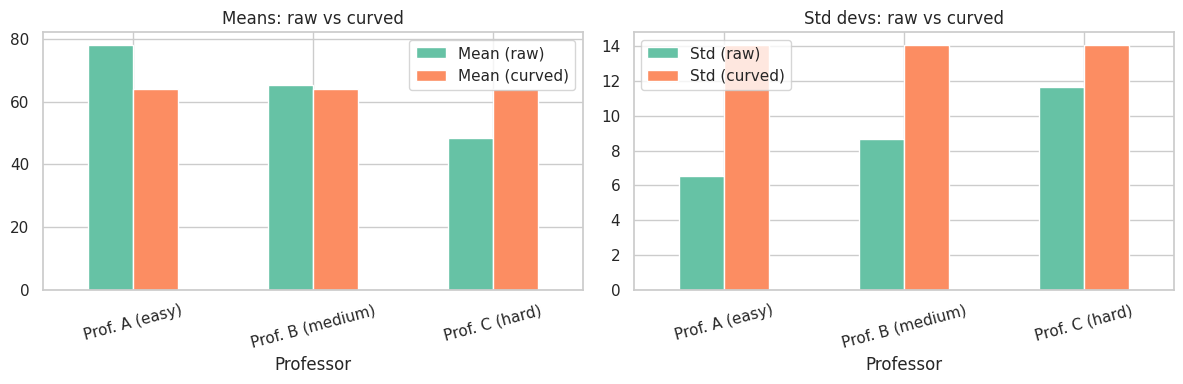

In [2]:

# =====================================================================
# Student Grade Curving System (A8) - single Colab cell
# 3x3 system solved by Gauss elimination
#
# ASSUMPTIONS
# 1. Linear curve y = a*x + b (a = scale, b = shift)
# 2. Variance condition a^2 sigma^2 = S^2 becomes a*sigma = S (a > 0, so
#    ranking is preserved). This keeps the system linear.
# 3. Population statistics (ddof = 0)
# 4. Default targets M, S = pooled mean and std of all students
# 5. Boundary: c = a*x_max + b is the curved top score, and c <= CAP.
#    If needed, S is lowered using M + S*z_max = CAP.
#
# SYSTEM (unknowns a, b, c per professor)
#   mu*a    + b     = M     (mean)
#   sigma*a         = S     (std / variance)
#   x_max*a + b - c = 0     (boundary)
# =====================================================================

# ============================ 1. IMPORTS =============================
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import seaborn as sns

try:
    display                      # available in Colab / Jupyter
except NameError:
    display = print

sns.set_theme(style="whitegrid", palette="Set2")
np.set_printoptions(precision=4, suppress=True)
pd.options.display.float_format = "{:.3f}".format

# ======================= 2. INPUTS AND DATASET =======================
TARGET_MEAN = None      # None -> pooled mean of all students
TARGET_STD  = None      # None -> pooled std of all students
CAP         = 100       # maximum allowed curved score
ENFORCE_CAP = True      # lower S automatically if top score would exceed CAP
VERBOSE     = True      # print Gauss elimination steps

# Benchmark: 3 professors, 40 students each, easy / medium / hard exams
rng = np.random.default_rng(42)

def make_scores(n, mean, sd):
    return np.clip(np.round(rng.normal(mean, sd, n)), 0, 100)

raw_scores = {
    "Prof. A (easy)":   make_scores(40, 78,  8),
    "Prof. B (medium)": make_scores(40, 65, 12),
    "Prof. C (hard)":   make_scores(40, 52, 15),
}
# To use your own data, replace the dict, e.g.
# raw_scores = {"Prof. X": [55, 62, ...], "Prof. Y": [...], "Prof. Z": [...]}

raw_scores = {k: np.asarray(v, dtype=float) for k, v in raw_scores.items()}
all_scores = np.concatenate(list(raw_scores.values()))
M = TARGET_MEAN if TARGET_MEAN is not None else all_scores.mean()
S = TARGET_STD  if TARGET_STD  is not None else all_scores.std()   # ddof=0
print(f"Target mean M = {M:.3f}, target std S = {S:.3f}, cap = {CAP}")

# ===================== 3. MATH ENGINE (GAUSS) ========================
def gauss_solve(A, b, verbose=False, label=""):
    """Solve A x = b by Gauss elimination with partial pivoting."""
    n = len(b)
    Ab = np.hstack([A.astype(float), b.reshape(-1, 1).astype(float)])  # [A|b]
    if verbose:
        print(f"\n--- Gauss elimination {label} ---\nAugmented [A|b]:\n{Ab}")

    # Forward elimination: zero out entries below each pivot
    for k in range(n):
        p = k + np.argmax(np.abs(Ab[k:, k]))        # partial pivoting
        if abs(Ab[p, k]) < 1e-12:
            raise ValueError("Singular system (is std = 0?).")
        if p != k:
            Ab[[k, p]] = Ab[[p, k]]
            if verbose: print(f"Swap R{k+1} <-> R{p+1}")
        for i in range(k + 1, n):
            f = Ab[i, k] / Ab[k, k]                  # multiplier
            Ab[i, k:] -= f * Ab[k, k:]               # Ri <- Ri - f*Rk
            if verbose: print(f"R{i+1} <- R{i+1} - ({f:.4f})*R{k+1}")
        if verbose: print(Ab)

    # Back substitution on the upper-triangular system
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Ab[i, -1] - Ab[i, i+1:n] @ x[i+1:]) / Ab[i, i]
    return x


def build_system(mu, sigma, x_max, M, S):
    """3x3 model for unknowns [a, b, c]."""
    A = np.array([[mu,    1, 0],     # mu*a + b = M
                  [sigma, 0, 0],     # sigma*a = S
                  [x_max, 1, -1]])   # x_max*a + b - c = 0
    rhs = np.array([M, S, 0.0])
    return A, rhs


def effective_target_std(raw_scores, M, S, cap, enforce):
    """Boundary equation M + S*z_max = cap gives S_cap = (cap - M)/z_max."""
    z_max = max((v.max() - v.mean()) / v.std() for v in raw_scores.values())
    S_cap = (cap - M) / z_max
    return (min(S, S_cap) if enforce else S), S_cap


S_eff, S_cap = effective_target_std(raw_scores, M, S, CAP, ENFORCE_CAP)
print(f"S requested = {S:.3f}, S allowed by cap = {S_cap:.3f}, S used = {S_eff:.3f}")

results, curved_scores = {}, {}
for name, x in raw_scores.items():
    mu, sigma, xmax = x.mean(), x.std(), x.max()
    A, rhs = build_system(mu, sigma, xmax, M, S_eff)
    a, b, c = gauss_solve(A, rhs, verbose=VERBOSE, label=f"for {name}")
    assert np.allclose(A @ [a, b, c], rhs), "Residual check failed"
    assert np.allclose([a, b, c], np.linalg.solve(A, rhs)), "Mismatch with NumPy"
    results[name] = dict(mu=mu, sigma=sigma, a=a, b=b, c=c)
    curved_scores[name] = a * x + b          # apply y = a*x + b to every student

# ======================== 4. OUTPUT DISPLAY ==========================
param_df = pd.DataFrame(results).T[["mu", "sigma", "a", "b", "c"]]
param_df.columns = ["Raw mean", "Raw std", "Scale a", "Shift b", "Curved top score c"]
print("\nSOLUTION OF THE 3x3 SYSTEMS (per professor)")
display(param_df)

rows = []
for name in raw_scores:
    r, c_ = raw_scores[name], curved_scores[name]
    rows.append([name, r.mean(), r.std(), r.max(),
                 c_.mean(), c_.std(), c_.max(), c_.min()])
stats_df = pd.DataFrame(rows, columns=[
    "Professor", "Mean (raw)", "Std (raw)", "Max (raw)",
    "Mean (curved)", "Std (curved)", "Max (curved)", "Min (curved)"]).set_index("Professor")
print("\nBEFORE vs AFTER CURVING")
display(stats_df)

ok_mean = np.allclose(stats_df["Mean (curved)"], M)
ok_std  = np.allclose(stats_df["Std (curved)"], S_eff)
ok_cap  = (stats_df["Max (curved)"] <= CAP + 1e-9).all()
print(f"Means match target : {ok_mean}\nStds match target  : {ok_std}\nWithin cap {CAP}   : {ok_cap}")
neg = sum((v < 0).sum() for v in curved_scores.values())
if neg:
    print(f"Note: {neg} curved scores fall below 0 (consider flooring at 0).")

# ================== 5. SYMPY EXACT VERIFICATION ======================
name0 = list(raw_scores)[0]
mu_s, sg_s, xm_s, M_s, S_s = sp.symbols("mu sigma x_max M S", positive=True)
a_, b_, c_s = sp.symbols("a b c")

eqs = [sp.Eq(mu_s*a_ + b_, M_s),
       sp.Eq(sg_s*a_, S_s),
       sp.Eq(xm_s*a_ + b_ - c_s, 0)]
sol = sp.solve(eqs, [a_, b_, c_s])
print("\nSymbolic solution:")
for k, v in sol.items():
    print(f"  {k} =", sp.simplify(v))

r0 = results[name0]
num = {mu_s: r0["mu"], sg_s: r0["sigma"], xm_s: raw_scores[name0].max(),
       M_s: M, S_s: S_eff}
print(f"\nNumeric check for {name0}:")
print("  SymPy :", [float(sol[s].subs(num)) for s in (a_, b_, c_s)])
print("  Gauss :", [r0["a"], r0["b"], r0["c"]])

# ============================ 6. CHARTS ==============================
colors = sns.color_palette("Set2", 3)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) Raw distributions
for (n, v), col in zip(raw_scores.items(), colors):
    sns.kdeplot(v, ax=axes[0, 0], label=n, color=col, fill=True, alpha=0.3)
axes[0, 0].set(title="Raw score distributions (different difficulty)", xlabel="Score")
axes[0, 0].legend()

# (2) Curved distributions
for (n, v), col in zip(curved_scores.items(), colors):
    sns.kdeplot(v, ax=axes[0, 1], label=n, color=col, fill=True, alpha=0.3)
axes[0, 1].axvline(M, color="k", ls="--", label=f"Target mean {M:.1f}")
axes[0, 1].set(title="Curved distributions (aligned mean & std)", xlabel="Score")
axes[0, 1].legend()

# (3) Scaling lines y = a x + b
xs = np.linspace(0, 100, 100)
for (n, r), col in zip(results.items(), colors):
    axes[1, 0].plot(xs, r["a"]*xs + r["b"], color=col, lw=2.5,
                    label=f"{n}: y={r['a']:.2f}x{r['b']:+.1f}")
axes[1, 0].plot(xs, xs, "k:", label="No curve (y = x)")
axes[1, 0].axhline(CAP, color="red", ls="--", alpha=.5, label="Cap")
axes[1, 0].set(title="Solved scaling functions", xlabel="Raw score",
               ylabel="Curved score", ylim=(0, 110))
axes[1, 0].legend(fontsize=8)

# (4) Boxplots before vs after
df_long = pd.concat(
    [pd.DataFrame({"Professor": n, "Score": v, "Stage": "Raw"}) for n, v in raw_scores.items()] +
    [pd.DataFrame({"Professor": n, "Score": v, "Stage": "Curved"}) for n, v in curved_scores.items()])
sns.boxplot(data=df_long, x="Professor", y="Score", hue="Stage", ax=axes[1, 1])
axes[1, 1].set(title="Spread before vs after curving")
axes[1, 1].tick_params(axis="x", labelsize=8)

plt.suptitle("Student Grade Curving System: 3x3 Gauss Elimination", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Mean and std comparison bars
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
stats_df[["Mean (raw)", "Mean (curved)"]].plot.bar(ax=ax[0], rot=15, title="Means: raw vs curved")
stats_df[["Std (raw)", "Std (curved)"]].plot.bar(ax=ax[1], rot=15, title="Std devs: raw vs curved")
plt.tight_layout()
plt.show()

In [3]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=param_df)

https://docs.google.com/spreadsheets/d/1o3tfaHTmx5BAnLqCK6Xs3KE8GL4gjXjBFAeFyoxEI84/edit#gid=0
